# Analysis of PELSA peptidomics data (Li et al, 2025)

## Study background

PELSA [1] is a novel proteomic method to investigate protein-ligand interactions through limited proteolysis. In a nutshell, proteins in solution (typically a cellular lysate) are briefly (typically between 1 and 4 minutes, depending on the specific protocol) treated with the protease trypsin at very high enzyme : substrate ratio (typically 1:2). Trypsin cuts the protein at K and R residues, but digesting very briefly means that only surface exposed K/R sites are actually cut. The critical assumption is that, if a ligand (such as a small molecule) is bound to the protein surface, it stablizes the surrounding protein region and digestion is momentarily slowed. It is worth noting that this is not strictly confined to actual steric blockage, but stablizing effects that extend beyond the ligand's footprint. The key to PELSA is that, when a ligand is present, K/R sites around the binding site are cut at slower rate than if the ligand is not present. If digestion is allowed to proceed for too long, this dynamic effect vanishes as the entire protein gets digested. However, the short digestion time means that peptides which are dynamically stabilized (i.e. ligand-adjacent) will appear as less abundant than their unbound control counterparts. We replicate the original publication's analysis of samples treated with Staurosporine, a pan-kinase binder, and its comparison against DMSO treated samples and visualize the regulation of kinase targets.

## Key proteomics methods and considerations

| Challenge | Why It Matters | Our Approach |
|-----------|---------------|--------------|
| **Missing values** | Proteomics data is ~20-50% missing (MNAR) | Evaluate whether imputation strategies improve results |
| **Dynamic range** | Precursors span 6+ orders of magnitude | Log-transform intensities |
| **Data layers** | Measurement is in precursors, but readout of regulated proteins is preferred | Evaluate published aggregation on UniProt ID and evaluate aggregation directly on gene name |


## References

[1]: Li, Kejia, et al. "A peptide-centric local stability assay enables proteome-scale identification of the protein targets and binding regions of diverse ligands." Nature Methods 22.2 (2025): 278-282.

## Analysis

In [ ]:
import tempfile
import pandas as pd
import numpy as np
import logging
import alphapepttools as apt  # import io, pp, pl, tl  # input/output, preprocessing, plotting and tools modules
from matplotlib.patches import Rectangle

logger = logging.getLogger(__name__)

### 1. Data loading
#### 1.1. Preparing the dataset using `alphapepttools` loaders and AnnData factory. 

For this study, the relevant files were obtained from study's PRIDE-repository (https://www.ebi.ac.uk/pride/archive/projects/PXD034606) and processed with DIANN 2.1.0. and a human spectral library. The resulting long-format precursor table is available through `alphapepttools`' data module. In addition, corresponding sample metadata has been added to differentiate Staurosporine-treated from control samples. Below is the list of .raw files which were processed for this notebook:

- LKJ_20211007_480_Hela_stau_0uM_1.raw
- LKJ_20211007_480_Hela_stau_0uM_2.raw
- LKJ_20211007_480_Hela_stau_0uM_3.raw
- LKJ_20211007_480_Hela_stau_0uM_4.raw
- LKJ_20211007_480_Hela_stau_20uM_1.raw
- LKJ_20211007_480_Hela_stau_20uM_2.raw
- LKJ_20211007_480_Hela_stau_20uM_3.raw
- LKJ_20211007_480_Hela_stau_20uM_4.raw

We have to extract protein-level intensities and precursor-level intensities from this dataset using the `alphapepttools.io.AnnDataFactory` class. The resulting AnnData object contains protein-group or precursor quantities and any number of feature-metadata columns (for example, protein groups may have genes as secondary annotation, precursors may have protein groups and genes as secondary annotation). Note that the names we use below to refere to columns are not actual DIANN fields. `read_psm_table` runs `alphabase`'s loaders under the hood, which standardize column names and sequence annotation syntax across all supported search engines.

In [ ]:
# Download the data using the alphapepttools data module
report_path = apt.data.get_data("pelsa_report_diann", output_dir=tempfile.mkdtemp())
sample_metadata_path = apt.data.get_data("pelsa_metadata", output_dir=tempfile.mkdtemp())

# Get the full report
full_report = pd.read_parquet(report_path)

# AnnDataFactory instance containing precursor level data
adata_precursor = apt.io.read_psm_table(
    file_paths=report_path,
    search_engine="diann",
    var_columns=["proteins", "genes", "sequence"],
)
# AnnDataFactory instance containing protein level data
adata_protein = apt.io.read_psm_table(
    file_paths=report_path,
    search_engine="diann",
    level="proteins",
    var_columns=["genes"],
)

# AnnDataFactory instance containing gene level data
adata_gene = apt.io.read_psm_table(
    file_paths=report_path,
    search_engine="diann",
    level="genes",
)

/var/folders/2l/hhd_z4hx3070zw8rlj4c3l940000gn/T/tmpy_wu60x7/report.parquet does not yet exist
/var/folders/2l/hhd_z4hx3070zw8rlj4c3l940000gn/T/tmpy_wu60x7/report.parquet successfully downloaded (70.8467435836792 MB)
/var/folders/2l/hhd_z4hx3070zw8rlj4c3l940000gn/T/tmppxsq31fn/iteration_L_literature_reprocessing_PELSA_samplemap.csv does not yet exist
/var/folders/2l/hhd_z4hx3070zw8rlj4c3l940000gn/T/tmppxsq31fn/iteration_L_literature_reprocessing_PELSA_samplemap.csv successfully downloaded (0.000179290771484375 MB)


#### 1.2. Adding sample metadata

We focus on Protein Groups and Precursors, and use `pp.add_metadata()` to merge the metadata into our AnnData instances. Note that `add_metadata` does not just concatenate shape-matched tables to data, but checks for matching indices. The advantage of this is that the same `AnnData` instance can be reannotated with multiple metadata tables which don't have to match the data in shape or order. 

Tip: Since the matching index is a prerequisite, it is sometimes helpful to map actual file names to metadata by a mapping dictionary as shown below. Generally, it is always preferred to set up metadata such that individual samples are already identified by their rawfile names, but in practice this is often not the case, necessitating a mapping step on some unique sample ID, derived from the rawfile name on the data side, and from the metadata columns on the metadata side.

In [ ]:
sample_metadata = pd.read_csv(sample_metadata_path)
display(sample_metadata)

# Create a unique identifier for each row in the sample metadata by combining the plate and running_count columns
sample_metadata["sample"] = sample_metadata["plate"] + "_" + sample_metadata["running_count"].astype(str)

# Create a mapping from the unique identifier to the original index in the adata_protein.obs_names
run_name_map = {"_".join(k.split("_")[-2:]): k for k in adata_protein.obs_names}
print(run_name_map)

# Replace the index of the sample metadata with the unique identifier and map it to the original index in adata_protein.obs_names
sample_metadata.index = sample_metadata["sample"].map(run_name_map)

,running_count,plate,treatment,instrument
0,1,0uM,CTRL,E480
1,2,0uM,CTRL,E480
2,3,0uM,CTRL,E480
3,4,0uM,CTRL,E480
4,1,20uM,Stauro,E480
5,2,20uM,Stauro,E480
6,3,20uM,Stauro,E480
7,4,20uM,Stauro,E480


{'0uM_1': 'LKJ_20211007_480_Hela_stau_0uM_1', '0uM_2': 'LKJ_20211007_480_Hela_stau_0uM_2', '0uM_3': 'LKJ_20211007_480_Hela_stau_0uM_3', '0uM_4': 'LKJ_20211007_480_Hela_stau_0uM_4', '20uM_1': 'LKJ_20211007_480_Hela_stau_20uM_1', '20uM_2': 'LKJ_20211007_480_Hela_stau_20uM_2', '20uM_3': 'LKJ_20211007_480_Hela_stau_20uM_3', '20uM_4': 'LKJ_20211007_480_Hela_stau_20uM_4'}


In [ ]:
# Add the metadata to all AnnData instances
adata_precursor = apt.pp.add_metadata(adata_precursor, sample_metadata, axis=0)
adata_protein = apt.pp.add_metadata(adata_protein, sample_metadata, axis=0)
adata_gene = apt.pp.add_metadata(adata_gene, sample_metadata, axis=0)

#### 1.3. Log2-transformation of proteomics data

We log2-transform our data, but keep the untransformed values in a separate layer called 'raw'. Due to underlying averaging operations, calculations like Coefficient of Variation (CV) should always be done on the non-log-transformed values (computing the mean of logged values carries different statistical implications than taking the mean of untransformed values).

In [ ]:
# First, move the original data to a new layer called "raw" to preserve it before log transformation
adata_precursor.layers["raw"] = adata_precursor.X.copy()
adata_protein.layers["raw"] = adata_protein.X.copy()
adata_gene.layers["raw"] = adata_gene.X.copy()

# Apply log-transformation. Note that the nanlog function automatically handles zeros and other invalid values, and prints a small summary to inform about special values encountered during the transformation.
apt.pp.nanlog(adata_precursor)
apt.pp.nanlog(adata_protein)
apt.pp.nanlog(adata_gene)

In [ ]:
# Inspect the log2-transformed values:
display(adata_protein.to_df().iloc[:5, :5])

# Raw values:
display(adata_protein.to_df(layer="raw").iloc[:5, :5])

proteins,A0A096LP55;P07919,A0A0B4J2F0,A0A1B0GUY1,A0A3B3IS91,A0A3B3IU46;Q9BTL3
raw_name,,,,,
LKJ_20211007_480_Hela_stau_0uM_1,21.790016,23.018673,24.692411,17.029541,23.745449
LKJ_20211007_480_Hela_stau_0uM_2,21.902254,23.051476,24.746101,17.110256,23.861660
LKJ_20211007_480_Hela_stau_0uM_3,21.277990,23.003662,24.555399,17.807335,23.645226
LKJ_20211007_480_Hela_stau_0uM_4,21.540596,23.048594,24.787121,16.149979,23.457727
LKJ_20211007_480_Hela_stau_20uM_1,21.918283,23.059902,24.633326,NaN,23.821888


proteins,A0A096LP55;P07919,A0A0B4J2F0,A0A1B0GUY1,A0A3B3IS91,A0A3B3IU46;Q9BTL3
raw_name,,,,,
LKJ_20211007_480_Hela_stau_0uM_1,3626171.50,8497893.0,27111686.0,133783.515625,14063468.0
LKJ_20211007_480_Hela_stau_0uM_2,3919543.50,8693320.0,28139656.0,141481.781250,15243168.0
LKJ_20211007_480_Hela_stau_0uM_3,2542808.25,8409926.0,24655366.0,229372.937500,13119653.0
LKJ_20211007_480_Hela_stau_0uM_4,3050461.00,8675965.0,28951204.0,72715.656250,11520718.0
LKJ_20211007_480_Hela_stau_20uM_1,3963336.50,8744247.0,26023742.0,NaN,14828694.0


### 2. Perform basic EDA on protein and precursor data

Since PELSA-assay precursor fold changes are generally smaller than e.g. pulldowns, it is especially important to control the spread of replicates. In other words, too high CVs will drown out the signal and cause high numbers of non-significant precursor fold-changes.

In [ ]:
apt.metrics.pooled_coefficient_of_variation(
    adata=adata_protein,
    group_key="treatment",
    layer="raw",
    inplace=True,
)

  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,

  mean = np.nanmean(data, axis=axis)

  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,

  mean = np.nanmean(data, axis=axis)



,pcv
CTRL,0.069925
Stauro,0.069185


In [ ]:
# Small custom function to generate CVs
# In the future, this could become an alphapepttools core functionality

import anndata as ad


def make_group_cvs(
    adata: ad.AnnData,
    group_column: str,
) -> None:
    """Calculate CVs for each group in group_columns and store them in adata.var"""
    levels = adata.obs[group_column].unique()
    for level in levels:
        group_adata = apt.pp.filter_by_metadata(adata, {group_column: level}, axis=0)
        stds = group_adata.to_df(layer="raw").std(axis=0)
        means = group_adata.to_df(layer="raw").mean(axis=0)
        adata.var[f"{level}_CV"] = stds / means


# Calculate CVs for the different groups in the condition column
make_group_cvs(adata_protein, "treatment")
make_group_cvs(adata_precursor, "treatment")

In [ ]:
adata_protein.var

,genes,CTRL_CV,Stauro_CV
proteins,,,
A0A096LP55;P07919,UQCRH;UQCRHL,0.186421,0.121477
A0A0B4J2F0,PIGBOS1,0.016122,0.056860
A0A1B0GUY1,MARCOL,0.068520,0.094859
A0A3B3IS91,POLGARF,0.446857,0.747352
A0A3B3IU46;Q9BTL3,RAMAC;RAMACL,0.116591,0.072693
...,...,...,...
Q9Y6X4,FAM169A,0.070699,0.072106
Q9Y6X8,ZHX2,0.025179,0.077652
Q9Y6X9,MORC2,0.038942,0.012699


We use `alphapepttools`' plotting syntax to generate a stylized panel with violin plots for sample group feature CVs, and to assess the median intensity of all features across samples.

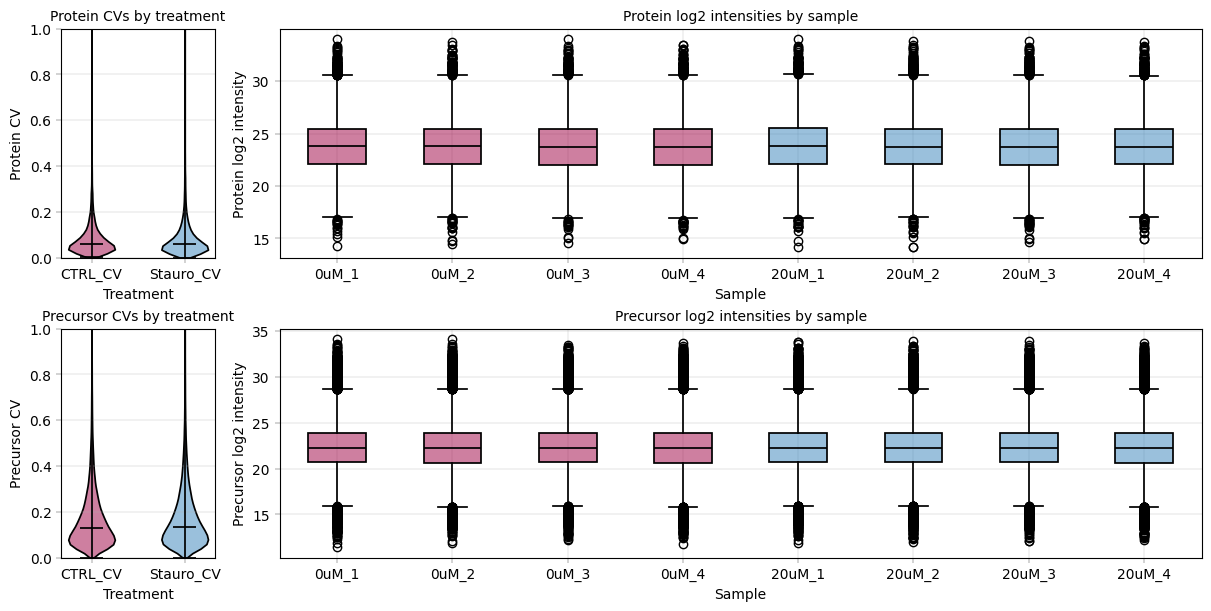

In [ ]:
fig, axm = apt.pl.create_figure(2, 2, figsize=(12, 6), gridspec_kwargs={"width_ratios": [0.5, 3]})

# Define color dictionary for the different treatments
color_dict = {
    "CTRL": apt.pl.BaseColors.get("red"),
    "Stauro": apt.pl.BaseColors.get("blue"),
}

# Map the sample names to their respective colors based on treatment
sample_color_dict = {
    sample: color_dict[treatment]
    for sample, treatment in zip(adata_protein.obs_names, adata_protein.obs["treatment"], strict=False)
}

# Iterative plotting
plot_data = {
    "protein": adata_protein,
    "precursor": adata_precursor,
}
for readout, adata in plot_data.items():
    # start with the CV plots
    ax = axm.next()
    apt.pl.Plots.violinplot(
        ax=ax,
        data=adata.T,
        direct_columns=["CTRL_CV", "Stauro_CV"],
        color_dict={f"{k}_CV": v for k, v in color_dict.items()},
    )
    ax.set_ylim(0, 1)

    apt.pl.label_axes(
        ax=ax,
        xlabel="Treatment",
        ylabel=f"{readout.capitalize()} CV",
        title=f"{readout.capitalize()} CVs by treatment",
    )

    # Then do the log2 abundance plots
    ax = axm.next()
    apt.pl.Plots.boxplot(
        ax=ax,
        data=adata.T,
        direct_columns=adata.obs_names.tolist(),
        color_dict=sample_color_dict,
    )

    # process x ticks to fit the plot better
    xtick_labels = [item.get_text() for item in ax.get_xticklabels()]  # Get xtick labels directly from axes
    xtick_labels = [
        "_".join(x.split("_")[-2:]) for x in xtick_labels
    ]  # Shorten the xtick labels to make them more readable
    _ = ax.set_xticklabels(xtick_labels)  # Set the new xtick labels

    apt.pl.label_axes(
        ax=ax,
        xlabel="Sample",
        ylabel=f"{readout.capitalize()} log2 intensity",
        title=f"{readout.capitalize()} log2 intensities by sample",
    )

    # save figure
    apt.pl.save_figure(
        fig=fig,  # Note that here we're using the whole figure to whose axes we added our plots
        filename="pelsa_quantities_overview.svg",
        output_dir="./example_outputs",
    )

### PELSA analysis depends on differential expression

Peptides from the stablized protein regions are expected to appear downregulated. We perform comparative differential expression analysis: 

- On the one hand, we evaluate "vanilla" independent two-sample t-test. 
- On the other, we employ `alphapepttools`' wrapper of `AlphaQuant` [1], a differential expression method specially adapted for mass-spectrometry proteomics data. 
- Additionally, we examine a Python-implementation of the popular *Limma* package's Empirical Bayes moderated ttest, which is more sophisticated than a simple ttest but considerably faster and more lightweight than alphaquant.

We want to retain the original AnnData object's feature-level metadata in our differential expression results, which can be accomplished by joining the `var` object to the results.

[1]: Ammar, Constantin, et al. "Tree-based quantification infers proteoform regulation in bottom-up proteomics data." bioRxiv (2025): 2025-03.

In [ ]:
comparison = ("Stauro", "CTRL")

In [ ]:
# Vanilla ttest on peptide data
ttest_peptide_results = apt.tl.diff_exp_ttest(
    adata=adata_precursor,
    between_column="treatment",
    comparison=comparison,
    min_valid_values=3,
    equal_var=False,
)
ttest_peptide_results = ttest_peptide_results.join(adata_precursor.var, how="left")

INFO:alphapepttools.tl.utils:Number of samples for Stauro: 4
INFO:alphapepttools.tl.utils:Number of samples for CTRL: 4


Comparing groups: Stauro vs CTRL


In [ ]:
# Run Limma Empirical Bayes moderated ttest on peptides: alphapepttools inmoose
ebayes_peptide_results = apt.tl.diff_exp_ebayes(
    adata=adata_precursor,
    between_column="treatment",
    comparison=comparison,
)[1]
ebayes_peptide_results = ebayes_peptide_results.join(adata_precursor.var, how="left")

INFO:alphapepttools.tl.diff_exp.ebayes:Running Limma eBayes differential expression analysis via inmoose
INFO:alphapepttools.tl.diff_exp.ebayes:Comparing levels: Stauro (treatment) vs CTRL (control)
INFO:alphapepttools.tl.utils:Number of samples for Stauro: 4
INFO:alphapepttools.tl.utils:Number of samples for CTRL: 4
INFO:root:pp.filter_data_completeness(): drop 23133 / 91803 features with >0.00 missing in any group.
INFO:alphapepttools.tl.diff_exp.ebayes:Computing contrast: condition[Stauro]-condition[CTRL]
INFO:alphapepttools.tl.diff_exp.ebayes:Design matrix dimensions: 8 samples x 2 groups
INFO:alphapepttools.tl.diff_exp.ebayes:Expression matrix dimensions: 68670 proteins x 8 samples


In [ ]:
# AlphaQuant ttest on full search engine output (takes approx. 3-4 minutes on a M2 MacBook Pro. Set "REPROCESS" flag to True to re-run, otherwise cached data will be used)
REPROCESS = False

if REPROCESS:
    comparison_key, alphaquant_results = apt.tl.diff_exp_alphaquant(
        adata=adata_precursor,
        report=full_report,
        between_column="treatment",
        comparison=comparison,
        valid_values_filter_mode="either",
        min_valid_values=3,
        plots="hide",
    )
    alphaquant_peptide_results = alphaquant_results["peptide"]
    alphaquant_peptide_results.to_pickle("./../example_data/notebook_02_alphaquant_peptide_results.pkl")
else:
    logger.info(" --> Using cached AlphaQuant results")
    alphaquant_peptide_results = pd.read_pickle("./../example_data/notebook_02_alphaquant_peptide_results.pkl")

INFO:__main__: --> Using cached AlphaQuant results


Alphaquant results are saved into a dictionary based on the quantification level:

- results
  - protein level results
  - proteoform level results
  - peptide level results

### We can use `alphapepttools` functionality to construct a volcanoplot function 

`alphapepttools` does not have a dedicated volcanoplotting function. However, it is straightforward to assemble one from the tools already implemented. In its basic form, a volcanoplot consists of:

- figure canvas (`pl.create_figure()`)
- scatterplot (`pl.Plots.scatter()`)
- lines (`pl.add_lines()`)
- labels (`pl.label_plot()`)
- axis labels (`pl.label_axes()`)

In the publication, peptides are aggregated into proteins in a nonstandard way: For each protein, the peptide with the highest significance is assigned its protein ID. This is how a dataset of peptides is converted into a dataset of proteins. We perform the same aggregation in our preprocessing.

In [ ]:
def top_peptides_to_proteins(
    ttest_df: pd.DataFrame,
    y_score_column: str = "-log10(p_value)",
    id_column: str = "protein",
) -> pd.DataFrame:
    """Convert peptide level t-test results to protein level by taking the top peptide per protein."""
    ttest_df = ttest_df.copy()
    return ttest_df.sort_values(y_score_column, ascending=False).groupby(id_column).first().reset_index()


aq_protein_table = top_peptides_to_proteins(alphaquant_peptide_results, id_column="protein")
eb_protein_table = top_peptides_to_proteins(ebayes_peptide_results, id_column="genes")
tt_protein_table = top_peptides_to_proteins(ttest_peptide_results, id_column="genes")

Additionally, we have to annotate all kinases in the data in order to visualize them and perform kinase enrichment scoring. To do this, we load a table from Gerard et al. [1] (http://www.kinhub.org/kinases.html) and transfer the annotations to our data. 

[1]: Manning, Gerard, et al. "The protein kinase complement of the human genome." Science 298.5600 (2002): 1912-1934.

In [ ]:
def annotate_kinases(
    ttest_df: pd.DataFrame,
    kinase_table_path: str,
    gene_id_column: str = "gene",
) -> list:
    """Assign str value for kinase/no kinase based on publication data:

    Manning, Gerard, et al. "The protein kinase complement of the human genome." Science 298.5600 (2002): 1912-1934.,
    table from: http://www.kinhub.org/kinases.html

    """
    ttest_df = ttest_df.copy()
    kinase_table = pd.read_excel(kinase_table_path)
    kinase_list = kinase_table["HGNC Name"].tolist()
    kinase_dict = dict(zip(kinase_list, ["kinase"] * len(kinase_list), strict=False))

    ttest_df["kinase_status"] = ttest_df[gene_id_column].map(kinase_dict).fillna("other")
    return ttest_df


# Download the kinase table using the alphapepttools data module
kinase_path = apt.data.get_data("kinase_table")

tt_protein_table = annotate_kinases(tt_protein_table, kinase_path, "genes")
eb_protein_table = annotate_kinases(eb_protein_table, kinase_path, "genes")
aq_protein_table = annotate_kinases(aq_protein_table, kinase_path, "protein")

/Users/vincenthbrennsteiner/Documents/mann_labs/_git_repositories/alphapepttools/docs/notebooks/studies/kinome_table.xlsx already exists (0.06418609619140625 MB)


### The main readout is a custom Kinase Enrichment Score:

In the main publication [1] and its follow-up [2], a kinase score is implemented to assess the sensitivity and specificity of the assay. This score derives from the fact that, in the ideal case we should only see kinase peptides downregulated. In practice, there are off-targets, i.e. peptides/proteins that appear as downregulated even though they are not kinases. The score is the ratio of downregulated (log2fc < 0) kinases/non-kinases at 80 % specificity when ranking by -log10(p_value). 

Imagine a boundary moving down from the highest point in the left half of the volcanoplot. Each time it passes a point, we count if the point is a kinase or a non-kinase. When the ratio of passed kinases / passed non-kinases becomes smaller than 0.8 we state that 80 % specificity is reached. However many kinases we have up to this point is our score.

[1]: Li, Kejia, et al. "A peptide-centric local stability assay to unveil protein targets of diverse ligands." bioRxiv (2023): 2023-10.

[2]: Li, Kejia, et al. "High-throughput peptide-centric local stability assay extends protein-ligand identification to membrane proteins, tissues, and bacteria." bioRxiv (2025): 2025-04.

In [ ]:
def kinase_score(
    ttest_df: pd.DataFrame,
    id_col: str,
    score_column: str = "-log10(p_value)",
    max_candidates: int = 500,
    threshold: float = 0.8,
) -> dict | None:
    """Perform kinase scoring analysis per HT-Pelsa.

    1. Sort peptides by -log10(significance) (score_column) descending
    2. Consider only regulated peptides, i.e. log2fc < 0
    3. Iterate through ranks, calculating the cumulative kinase fraction
         (number of kinases / total number of peptides)
    4. Stop when kinase fraction drops below min_kinase_pct or max_candidates is reached

    """
    ttest_df = ttest_df.copy()
    print(
        f"Total unique kinases in the dataset: {ttest_df.loc[ttest_df['kinase_status'] == 'kinase', id_col].nunique()}"
    )

    # Restrict to downregulated peptides
    ttest_df = ttest_df[ttest_df["log2fc"] < 0]
    print(
        f"Total unique kinases in the downregulated dataset: {ttest_df.loc[ttest_df['kinase_status'] == 'kinase', id_col].nunique()}"
    )

    # Rank peptides by score
    ttest_df = ttest_df.sort_values(score_column, ascending=False).reset_index(drop=True)
    ttest_df["rank"] = ttest_df.index + 1

    # Iterate through ranks and record the kinase fraction
    def _kinase_fraction(df: pd.DataFrame) -> float:
        kinase_count = df[df["kinase_status"] == "kinase"].shape[0]
        total_count = df.shape[0]
        return kinase_count / total_count if total_count > 0 else np.nan

    kinase_fractions = []
    for n in range(1, len(ttest_df) + 1):
        subset = ttest_df.head(n)
        kinase_fraction = _kinase_fraction(subset)
        score_threshold = subset[score_column].iloc[-1]
        kinase_fractions.append(
            {
                "rank": n,
                "kinase_fraction": kinase_fraction,
                "score_threshold": score_threshold,
                "n_kinases": subset[subset["kinase_status"] == "kinase"].shape[0],
                "n_total": subset.shape[0],
            }
        )

        if n >= max_candidates and kinase_fraction < threshold:
            break

    kinase_fraction_df = pd.DataFrame(kinase_fractions)

    # Determine score based on specificity threshold
    above_threshold = kinase_fraction_df[kinase_fraction_df["kinase_fraction"] >= threshold]
    optimal_row = above_threshold.iloc[-1] if not above_threshold.empty else None
    if optimal_row is None:
        print("No suitable threshold found.")
        return None

    return {
        "threshold": optimal_row["score_threshold"],
        "n_candidates": optimal_row["rank"],
        "n_kinases": optimal_row["n_kinases"],
        "n_non_kinases": optimal_row["n_total"] - optimal_row["n_kinases"],
        "kinase_percentage": optimal_row["kinase_fraction"],
    }

In [ ]:
# uniform coloring
color_dict = {
    "kinase": apt.pl.BaseColors.get("red"),
    "other": apt.pl.BaseColors.get("grey"),
}

### First, inspect the aggregated protein results for the standard t-test

In [ ]:
tt_protein_table

,genes,condition_pair,protein,log2fc,p_value,-log10(p_value),fdr,-log10(fdr),method,max_level_1_samples,max_level_2_samples,proteins,sequence,CTRL_CV,Stauro_CV,kinase_status
0,,Stauro_VS_CTRL,TQNNLESDYLAR2,-0.087669,0.150267,0.823137,0.981499,0.008110,ttest,4,4,Q6ZSR9,TQNNLESDYLAR,0.048224,0.055414,other
1,AAAS,Stauro_VS_CTRL,GQVTLYEHNNELVTGSSYESPPPDFR3,0.102932,0.254376,0.594524,0.981499,0.008110,ttest,4,4,Q9NRG9,GQVTLYEHNNELVTGSSYESPPPDFR,0.054801,0.097589,other
2,AACS,Stauro_VS_CTRL,FSGIVFSR2,-0.301529,0.011841,1.926604,0.741739,0.129749,ttest,4,4,Q86V21,FSGIVFSR,0.079934,0.086473,other
3,AAGAB,Stauro_VS_CTRL,AATLPHEQR2,-0.190069,0.469171,0.328669,0.982237,0.007784,ttest,4,4,Q6PD74,AATLPHEQR,0.127257,0.258282,other
4,AAK1,Stauro_VS_CTRL,VQTTPPPAVQGQK2,-0.127951,0.373769,0.427397,0.981499,0.008110,ttest,4,4,Q2M2I8-2;Q2M2I8,VQTTPPPAVQGQK,0.057749,0.167960,kinase
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7311,ZWINT,Stauro_VS_CTRL,LLFPEAEAEAENLPDDKPQQPTRPQEQSTGDTMGR4,0.588341,0.028182,1.550036,0.907525,0.042141,ttest,4,4,O95229,LLFPEAEAEAENLPDDKPQQPTRPQEQSTGDTMGR,0.217788,0.152874,other
7312,ZYG11A,Stauro_VS_CTRL,VLGLLNNIAEVR2,-0.193054,0.188798,0.724004,0.981499,0.008110,ttest,4,4,Q6WRX3,VLGLLNNIAEVR,0.127255,0.117065,other
7313,ZYX,Stauro_VS_CTRL,FGPVVAPK2,-0.410635,0.030154,1.520659,0.911101,0.040433,ttest,4,4,Q15942,FGPVVAPK,0.108667,0.168300,other
7314,ZZEF1,Stauro_VS_CTRL,KTDYFFLEVQK3,-0.222265,0.134206,0.872228,0.981499,0.008110,ttest,4,4,O43149,KTDYFFLEVQK,0.114294,0.130692,other


In [ ]:
tt_protein_table

,genes,condition_pair,protein,log2fc,p_value,-log10(p_value),fdr,-log10(fdr),method,max_level_1_samples,max_level_2_samples,proteins,sequence,CTRL_CV,Stauro_CV,kinase_status
0,,Stauro_VS_CTRL,TQNNLESDYLAR2,-0.087669,0.150267,0.823137,0.981499,0.008110,ttest,4,4,Q6ZSR9,TQNNLESDYLAR,0.048224,0.055414,other
1,AAAS,Stauro_VS_CTRL,GQVTLYEHNNELVTGSSYESPPPDFR3,0.102932,0.254376,0.594524,0.981499,0.008110,ttest,4,4,Q9NRG9,GQVTLYEHNNELVTGSSYESPPPDFR,0.054801,0.097589,other
2,AACS,Stauro_VS_CTRL,FSGIVFSR2,-0.301529,0.011841,1.926604,0.741739,0.129749,ttest,4,4,Q86V21,FSGIVFSR,0.079934,0.086473,other
3,AAGAB,Stauro_VS_CTRL,AATLPHEQR2,-0.190069,0.469171,0.328669,0.982237,0.007784,ttest,4,4,Q6PD74,AATLPHEQR,0.127257,0.258282,other
4,AAK1,Stauro_VS_CTRL,VQTTPPPAVQGQK2,-0.127951,0.373769,0.427397,0.981499,0.008110,ttest,4,4,Q2M2I8-2;Q2M2I8,VQTTPPPAVQGQK,0.057749,0.167960,kinase
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7311,ZWINT,Stauro_VS_CTRL,LLFPEAEAEAENLPDDKPQQPTRPQEQSTGDTMGR4,0.588341,0.028182,1.550036,0.907525,0.042141,ttest,4,4,O95229,LLFPEAEAEAENLPDDKPQQPTRPQEQSTGDTMGR,0.217788,0.152874,other
7312,ZYG11A,Stauro_VS_CTRL,VLGLLNNIAEVR2,-0.193054,0.188798,0.724004,0.981499,0.008110,ttest,4,4,Q6WRX3,VLGLLNNIAEVR,0.127255,0.117065,other
7313,ZYX,Stauro_VS_CTRL,FGPVVAPK2,-0.410635,0.030154,1.520659,0.911101,0.040433,ttest,4,4,Q15942,FGPVVAPK,0.108667,0.168300,other
7314,ZZEF1,Stauro_VS_CTRL,KTDYFFLEVQK3,-0.222265,0.134206,0.872228,0.981499,0.008110,ttest,4,4,O43149,KTDYFFLEVQK,0.114294,0.130692,other


Total unique kinases in the dataset: 276
Total unique kinases in the downregulated dataset: 215
Kinase scoring threshold at -log10(p_value) = 3.34, covering 108.0 proteins with 87.0 kinases (80.6%)


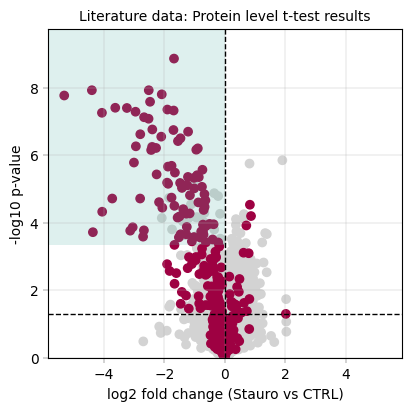

In [ ]:
fig, axm = apt.pl.create_figure(1, 1, figsize=(4, 4))
ax = axm.next()

apt.pl.Plots.volcano(
    ax=ax,
    data=tt_protein_table,
    x_column="log2fc",
    y_column="-log10(p_value)",
    color_dict=color_dict,
    layers={
        ("kinase_status", "kinase", "kinase"),  # column, filter value, color name
        ("kinase_status", "other", "other"),
    },
    x_thresholds=(0),
)

apt.pl.label_axes(
    ax=ax,
    xlabel="log2 fold change (Stauro vs CTRL)",
    ylabel="-log10 p-value",
    title="Literature data: Protein level t-test results",
)

# Computing the kinase score at a set threshold & small message to summarize the results
ttest_ks_result = kinase_score(tt_protein_table, id_col="genes", threshold=0.8)
print(
    f"Kinase scoring threshold at -log10(p_value) = {ttest_ks_result['threshold']:.2f}, covering {ttest_ks_result['n_candidates']} proteins with {ttest_ks_result['n_kinases']} kinases ({ttest_ks_result['kinase_percentage'] * 100:.1f}%)"
)

# For better visualization, we draw a rectangle to indicate the kinase scoring threshold
left_bound = ax.get_xlim()[0]
upper_bound = ax.get_ylim()[1]
rect = Rectangle(
    xy=(
        left_bound,
        ttest_ks_result["threshold"],
    ),  # Bottom-left corner: x value is the left bound of the plot, y value is the kinase scoring threshold
    width=np.abs(0 - left_bound),  # Width from the left bound to 0, indicating that we focus on downregulated ids
    height=upper_bound - ttest_ks_result["threshold"],  # Height to figure top
    linewidth=2,
    facecolor=apt.pl.BaseColors.get("green", alpha=0.2),
)
ax.add_patch(rect)

# save figure
apt.pl.save_figure(
    fig=fig,  # Note that here we're using the whole figure to whose axes we added our plots
    filename="Literature_PELSA_TTEST_AggProt_Stauro.svg",
    output_dir="./example_outputs",
)

### Next, inspect the protein-aggregated results from the Empirical Bayes moderated ttest (Limma-like)

Total unique kinases in the dataset: 253
Total unique kinases in the downregulated dataset: 197
Kinase scoring threshold at -log10(p_value) = 3.57, covering 117.0 proteins with 94.0 kinases (80.3%)


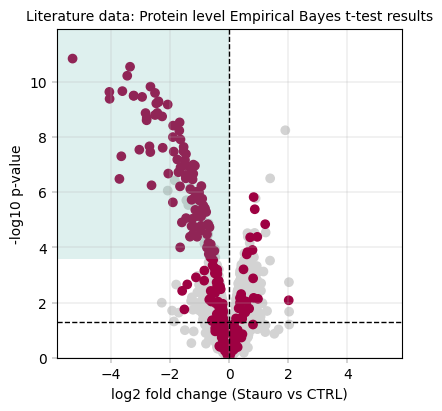

In [ ]:
fig, axm = apt.pl.create_figure(1, 1, figsize=(4, 4))
ax = axm.next()

apt.pl.Plots.volcano(
    ax=ax,
    data=eb_protein_table,
    x_column="log2fc",
    y_column="-log10(p_value)",
    color_dict=color_dict,
    layers={
        ("kinase_status", "kinase", "kinase"),  # column, filter value, color name
        ("kinase_status", "other", "other"),
    },
    x_thresholds=(0),
)

apt.pl.label_axes(
    ax=ax,
    xlabel="log2 fold change (Stauro vs CTRL)",
    ylabel="-log10 p-value",
    title="Literature data: Protein level Empirical Bayes t-test results",
)

# Computing the kinase score at a set threshold & small message to summarize the results
ebayes_ttest_ks_results = kinase_score(eb_protein_table, id_col="genes", threshold=0.8)
print(
    f"Kinase scoring threshold at -log10(p_value) = {ebayes_ttest_ks_results['threshold']:.2f}, covering {ebayes_ttest_ks_results['n_candidates']} proteins with {ebayes_ttest_ks_results['n_kinases']} kinases ({ebayes_ttest_ks_results['kinase_percentage'] * 100:.1f}%)"
)

# For better visualization, we draw a rectangle to indicate the kinase scoring threshold
left_bound = ax.get_xlim()[0]
upper_bound = ax.get_ylim()[1]
rect = Rectangle(
    xy=(
        left_bound,
        ebayes_ttest_ks_results["threshold"],
    ),  # Bottom-left corner: x value is the left bound of the plot, y value is the kinase scoring threshold
    width=np.abs(0 - left_bound),  # Width from the left bound to 0, indicating that we focus on downregulated ids
    height=upper_bound - ebayes_ttest_ks_results["threshold"],  # Height to figure top
    linewidth=2,
    facecolor=apt.pl.BaseColors.get("green", alpha=0.2),
)
ax.add_patch(rect)

# save figure
apt.pl.save_figure(
    fig=fig,  # Note that here we're using the whole figure to whose axes we added our plots
    filename="Literature_PELSA_EBAYES_TTEST_AggProt_Stauro.svg",
    output_dir="./example_outputs",
)

### Next, inspect the protein-aggregated results from Alphaquant

Total unique kinases in the dataset: 276
Total unique kinases in the downregulated dataset: 215
Kinase scoring threshold at -log10(p_value) = 3.40, covering 137.0 proteins with 110.0 kinases (80.3%)


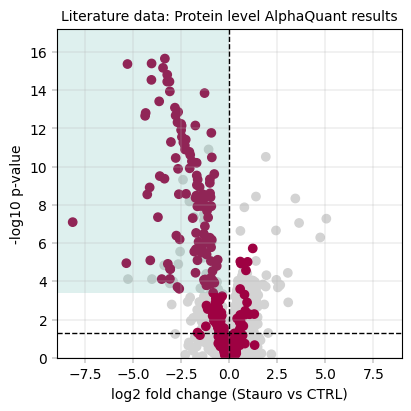

In [ ]:
fig, axm = apt.pl.create_figure(1, 1, figsize=(4, 4))
ax = axm.next()

apt.pl.Plots.volcano(
    ax=ax,
    data=aq_protein_table,
    x_column="log2fc",
    y_column="-log10(p_value)",
    color_dict=color_dict,
    layers={
        ("kinase_status", "kinase", "kinase"),  # column, filter value, color name
        ("kinase_status", "other", "other"),
    },
    x_thresholds=(0),
)

apt.pl.label_axes(
    ax=ax,
    xlabel="log2 fold change (Stauro vs CTRL)",
    ylabel="-log10 p-value",
    title="Literature data: Protein level AlphaQuant results",
)

# Computing the kinase score at a set threshold & small message to summarize the results
aq_ks_result = kinase_score(aq_protein_table, id_col="protein", threshold=0.8)
print(
    f"Kinase scoring threshold at -log10(p_value) = {aq_ks_result['threshold']:.2f}, covering {aq_ks_result['n_candidates']} proteins with {aq_ks_result['n_kinases']} kinases ({aq_ks_result['kinase_percentage'] * 100:.1f}%)"
)

# For better visualization, we draw a rectangle to indicate the kinase scoring threshold
left_bound = ax.get_xlim()[0]
upper_bound = ax.get_ylim()[1]
rect = Rectangle(
    xy=(
        left_bound,
        aq_ks_result["threshold"],
    ),  # Bottom-left corner: x value is the left bound of the plot, y value is the kinase scoring threshold
    width=np.abs(0 - left_bound),  # Width from the left bound to 0, indicating that we focus on downregulated ids
    height=upper_bound - aq_ks_result["threshold"],  # Height to figure top
    linewidth=2,
    facecolor=apt.pl.BaseColors.get("green", alpha=0.2),
)
ax.add_patch(rect)

# save figure
apt.pl.save_figure(
    fig=fig,  # Note that here we're using the whole figure to whose axes we added our plots
    filename="Literature_PELSA_AlphaQuant_AggProt_Stauro.svg",
    output_dir="./example_outputs",
)

### Visualize the kinase enrichment results compared to literature data

In Figure 2 b of Kejia, Li et al., the number of downregulated vs. kinase proteins at 80 % specificity (as computed above) is given at 135 downregulated candidates and 108 kinase targets. Note that their result were computed using an Empirical Bayes test. We can visualize this data and compare to our `alphapepttools` differential expression data:

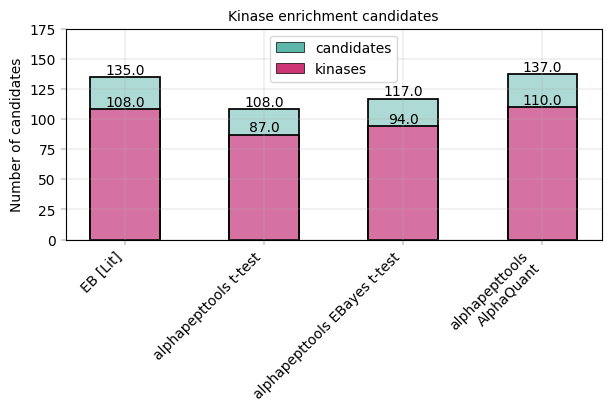

In [ ]:
total_candidates = pd.DataFrame(
    {
        "group": ["EB [Lit]", "alphapepttools t-test", "alphapepttools EBayes t-test", "alphapepttools\nAlphaQuant"],
        "value": [
            135,
            ttest_ks_result["n_candidates"],
            ebayes_ttest_ks_results["n_candidates"],
            aq_ks_result["n_candidates"],
        ],
    }
)

total_kinases = pd.DataFrame(
    {
        "group": ["EB [Lit]", "alphapepttools t-test", "alphapepttools EBayes t-test", "alphapepttools\nAlphaQuant"],
        "value": [108, ttest_ks_result["n_kinases"], ebayes_ttest_ks_results["n_kinases"], aq_ks_result["n_kinases"]],
    }
)

color_dict = {
    "candidates": apt.pl.BaseColors.get("green"),
    "kinases": apt.pl.BaseColors.get("red", lighten=0.1, alpha=0.8),
}

fig, axm = apt.pl.create_figure(1, 1, figsize=(6, 4))

# First, plot the total candidates
ax = axm.next()
ax.set_ylim(0, 175)

apt.pl.Plots.barplot(
    ax=ax,
    data=total_candidates,
    grouping_column="group",
    value_column="value",
    color=apt.pl.BaseColors.get("green"),
)

total_candidates["position"] = range(1, len(total_candidates) + 1)
apt.pl.label_plot(
    ax=ax,
    data=total_candidates,
    x_column="position",
    y_column="value",
    label_column="value",
    label_kwargs={"va": "bottom", "ha": "center"},
)

# Then, add the kinases
apt.pl.Plots.barplot(
    ax=ax,
    data=total_kinases,
    grouping_column="group",
    value_column="value",
    color=apt.pl.BaseColors.get("red", lighten=0.3),
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

total_kinases["position"] = range(1, len(total_kinases) + 1)
apt.pl.label_plot(
    ax=ax,
    data=total_kinases,
    x_column="position",
    y_column="value",
    label_column="value",
    label_kwargs={"va": "bottom", "ha": "center"},
)

apt.pl.label_axes(
    ax=ax,
    xlabel="",
    ylabel="Number of candidates",
    title="Kinase enrichment candidates",
)

apt.pl.add_legend_to_axes(
    ax=ax,
    levels=color_dict,
)


# save figure
apt.pl.save_figure(
    fig=fig,  # Note that here we're using the whole figure to whose axes we added our plots
    filename="Literature_PELSA_Kinase_Enrichment_Candidates_Comparison.svg",
    output_dir="./example_outputs",
)

### In summary, we saw that `alphapepttools`...

- can swiftly load precursor and protein data into `AnnData` instances
- contains standardized, 'plug and play' modules for proteomics differential expression
- Equals/outperforms the empirical Bayes approach from literature, demonstrating that we have a strong framework for analysing PELSA-data in-house using `AlphaQuant`.